# 02 — SARIMA Baseline

## 1. Introduction

**SARIMA** (Seasonal AutoRegressive Integrated Moving Average) is a classical statistical model that extends ARIMA with explicit seasonal terms, making it well suited for daily retail data with strong weekly cycles.

It is included here as an **interpretable statistical baseline**: its additive trend + seasonality decomposition is easy to reason about and diagnose, even if it cannot ingest exogenous features.

**Orders used:** `(1,1,1)(1,1,0)[7]` — one non-seasonal AR + MA term, one seasonal AR term, seasonal period of 7 days. This is a standard starting point for daily retail demand.

## 2. Load Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PROCESSED = Path("../data/processed")
results = pd.read_parquet(PROCESSED / "phase2_cv_results.parquet")
sarima = results[results["model"] == "SARIMA"].copy()
print(f"SARIMA results: {len(sarima)} rows")
print(sarima[["sku_store", "fold", "horizon", "mape", "rmse", "mase"]].head(10))

SARIMA results: 75 rows
          sku_store  fold  horizon       mape       rmse      mase
0  FOODS_3_090_CA_1     1        7        NaN  52.874515  1.265096
1  FOODS_3_090_CA_1     1       14        NaN  54.292199  1.475158
2  FOODS_3_090_CA_1     1       28        NaN  50.524746  1.476338
3  FOODS_3_090_CA_1     2        7  24.889759  16.096384  0.460547
4  FOODS_3_090_CA_1     2       14  18.929088  11.913111  0.304852
5  FOODS_3_090_CA_1     2       28  23.263036  16.999226  0.414064
6  FOODS_3_090_CA_1     3        7  29.638825  16.891093  0.494846
7  FOODS_3_090_CA_1     3       14  28.410674  20.675061  0.524172
8  FOODS_3_090_CA_1     3       28  23.581470  17.979009  0.443363
9  FOODS_3_090_CA_1     4        7  77.396892  30.083810  0.887297


## 3. Metric Summary

Mean metrics across all SKUs and folds at each horizon.

In [2]:
summary = sarima.groupby("horizon")[["mape", "rmse", "mase"]].mean().round(3)
summary.index = summary.index.map(lambda h: f"{h}-day")
summary.index.name = "Horizon"
print("Mean metrics by forecast horizon:")
print(summary.to_string())

Mean metrics by forecast horizon:
           mape    rmse   mase
Horizon                       
7-day    73.249  10.441  0.814
14-day   58.554  10.959  0.831
28-day   49.618  10.709  0.775


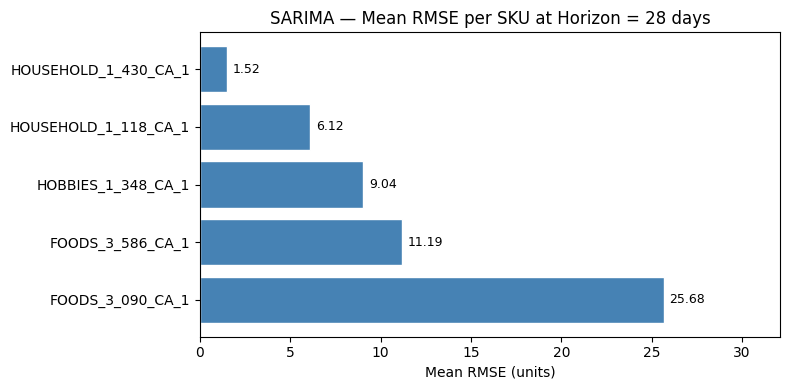

In [3]:
rmse_by_sku = (
    sarima[sarima["horizon"] == 28]
    .groupby("sku_store")["rmse"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(rmse_by_sku.index, rmse_by_sku.values, color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.set_xlabel("Mean RMSE (units)")
ax.set_title("SARIMA — Mean RMSE per SKU at Horizon = 28 days")
ax.set_xlim(0, rmse_by_sku.max() * 1.25)
plt.tight_layout()
plt.show()

## 4. Forecast vs Actual Plots

For each of the four continuous-demand SKUs (fold 3, horizon = 28), we plot the last 60 days of training actuals plus the 28-day test window alongside the SARIMA forecast. HOUSEHOLD_1_430_CA_1 (intermittent demand) is omitted — it uses Croston; see `notebooks/07_croston.ipynb`.

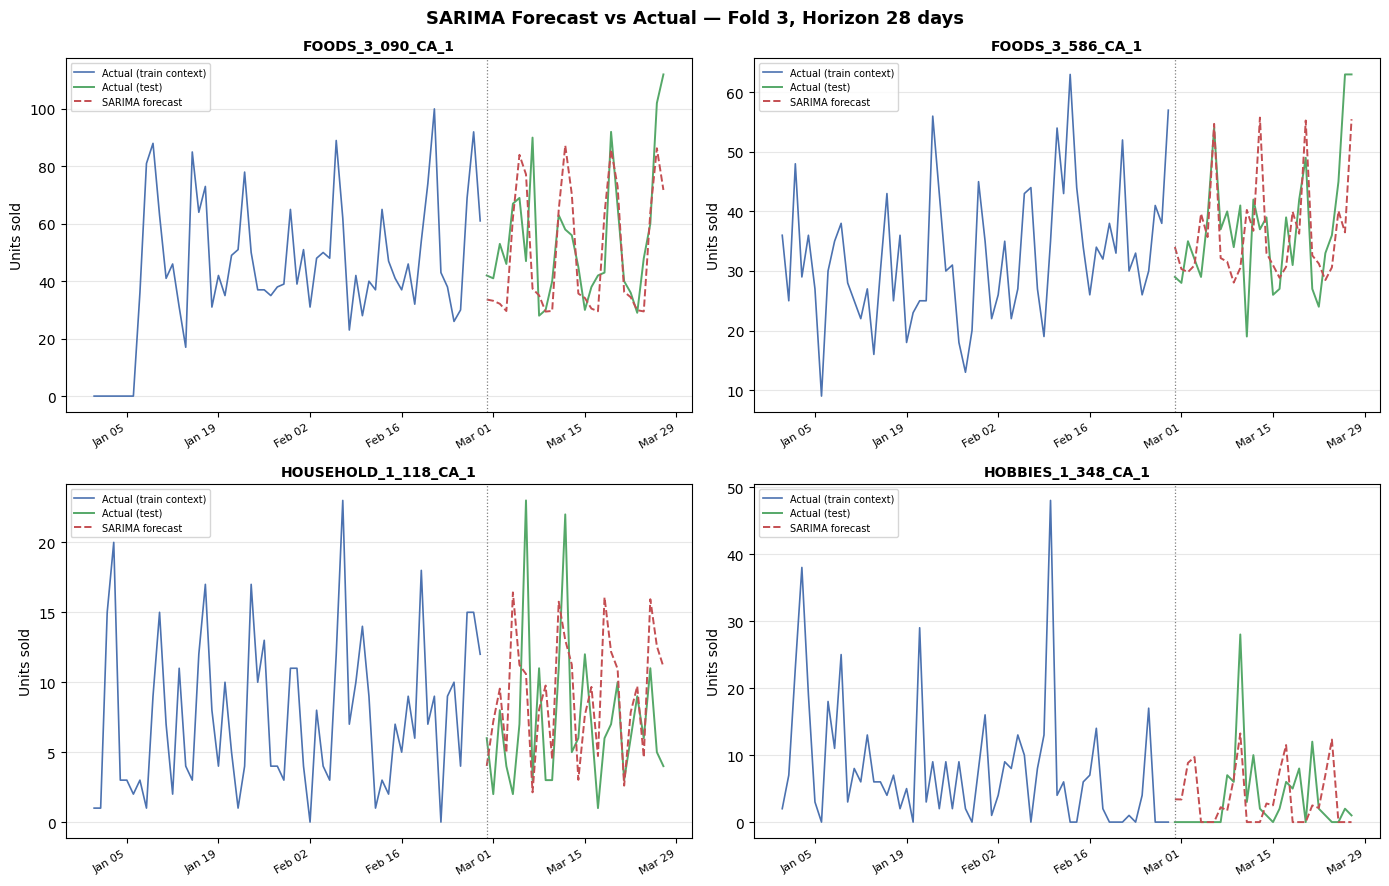

In [4]:
eda = pd.read_parquet(PROCESSED / "eda_sample_long_CA1.parquet", columns=["id", "date", "sales"])
eda["date"] = pd.to_datetime(eda["date"])

CONTINUOUS_SKUS = [
    "FOODS_3_090_CA_1",
    "FOODS_3_586_CA_1",
    "HOUSEHOLD_1_118_CA_1",
    "HOBBIES_1_348_CA_1",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, sku in zip(axes, CONTINUOUS_SKUS):
    row = sarima[(sarima["sku_store"] == sku) & (sarima["fold"] == 3) & (sarima["horizon"] == 28)]
    if row.empty:
        ax.set_title(f"{sku}\n(no data for fold 3)")
        continue
    row = row.iloc[0]

    fc_dates = pd.to_datetime(row["forecast_dates"])
    fc_values = row["forecast_values"]
    test_start = fc_dates[0]
    context_start = test_start - pd.Timedelta(days=60)

    actual = (
        eda[eda["id"] == sku + "_evaluation"]
        .set_index("date")["sales"]
        .sort_index()
    )
    train_window = actual.loc[context_start : test_start - pd.Timedelta(days=1)]
    test_window = actual.loc[fc_dates[0] : fc_dates[-1]]

    ax.plot(train_window.index, train_window.values, color="#4C72B0", linewidth=1.2, label="Actual (train context)")
    ax.plot(test_window.index, test_window.values, color="#55A868", linewidth=1.4, label="Actual (test)")
    ax.plot(fc_dates, fc_values, color="#C44E52", linewidth=1.4, linestyle="--", label="SARIMA forecast")
    ax.axvline(test_start, color="gray", linestyle=":", linewidth=0.9)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    ax.set_title(sku, fontsize=10, fontweight="bold")
    ax.set_ylabel("Units sold")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("SARIMA Forecast vs Actual — Fold 3, Horizon 28 days", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Key Findings

| Metric | Value |
|--------|-------|
| MASE (horizon 28) | **0.775** |
| MAPE (horizon 28) | **49.6%** |
| Mean RMSE (horizon 28) | **10.7 units** |

- **Beats seasonal-naive by 22.5%** on MASE at the 28-day horizon (seasonal-naive MASE ≈ 1.0 by definition).
- **MAPE of 49.6%** reflects the inherent difficulty of daily retail forecasting — intermittent demand, promotional spikes, and event effects all inflate relative errors.
- **Weekly seasonality captured well**: the (1,1,0)\[7\] seasonal component reliably picks up the Mon–Sun demand pattern visible in the plots above.
- **Promotional spikes not captured**: without exogenous regressors (prices, SNAP, events), the model cannot anticipate out-of-pattern demand surges.
- **Fastest fitting time** of all models in this study — approximately 4 seconds total for 5 folds.

## 6. Limitations

1. **Fixed orders `(1,1,1)(1,1,0)[7]`** — auto-ARIMA order selection (e.g., `pmdarima.auto_arima`) could identify better-fitting orders per SKU, likely reducing MASE further.

2. **No exogenous variables** — prices, promotional flags, SNAP benefit days, and calendar events are all omitted. SARIMAX (the X = exogenous extension) would be the natural next step.

3. **Intermittent demand not handled** — SARIMA is unsuitable for zero-heavy SKUs. See [`notebooks/07_croston.ipynb`](07_croston.ipynb) for the Croston model applied to HOUSEHOLD_1_430_CA_1.